## Notebook 7 — Oudin vs. Penman-Monteith WBM AET, both vs. OpenET

Notebook 06 compared the Oudin- and Penman-Monteith-driven WBM runs directly
against *each other*. This notebook instead benchmarks each of them against
**OpenET** (the same 4 km gridcell-averaged ensemble notebook 04 uses to
validate/calibrate the default Oudin run) -- the same comparison notebook 04
does for Oudin, done here for both PET methods side by side.

For each method, this produces:
- Per-site bias (MBE), MAE, RMSE, R², and slope vs. OpenET
- Faceted 1:1 scatter plots (WBM AET vs. OpenET, one panel per site)
- A grouped bar chart of mean RMSE by ecosystem, Oudin vs. Penman-Monteith

**Scope / assumptions:**
- This is an **uncalibrated** comparison -- it doesn't apply notebook 04's
  PET-multiplier calibration to either run. Both methods are compared as-is
  (Penman-Monteith with `Kc = 1.0`, per notebook 06's banner).
- OpenET only reports actual ET, not a PET-equivalent, so the comparison here
  is AET vs. OpenET only (PET itself is already compared directly between the
  two methods in notebook 06).
- This notebook only reads cached CSVs -- it doesn't run the WBM or touch
  Earth Engine.

**Prerequisites:** run notebooks 01→02→3 at least once (Oudin WBM run,
OpenET, and gridMET climate caches), and notebook 06 at least once
(Penman-Monteith WBM cache: `Data/gridmet_cache/wbm_results_penman_monteith.csv`).

# Setup Workspace

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.lines as mlines

pd.set_option("display.width", 120)
print("Imports OK -- this notebook only reads cached CSVs, no GEE/raster access needed.")


Imports OK -- this notebook only reads cached CSVs, no GEE/raster access needed.


### Load cached prerequisites (notebooks 02, 03, 06)

In [2]:
# ── Load cached outputs from notebooks 02 (OpenET), 03 (Oudin WBM run), and
# 06 (Penman-Monteith WBM run) -- no GEE or raster access needed here. ─────────
flux_towers = pd.read_csv("../Data/geo_data/flux_towers.csv")

openet_gridcell_df = pd.read_csv(
    "../Data/open_et_gridcell/openet_gridcell_timeseries.csv",
    parse_dates=["date"]
)

wbm_results_oudin = pd.read_csv(
    "../Data/gridmet_cache/wbm_results_flux_towers_2016_2023.csv",
    parse_dates=["date"]
)
wbm_results_pm = pd.read_csv(
    "../Data/gridmet_cache/wbm_results_penman_monteith.csv",
    parse_dates=["date"]
)

# Both WBM caches were produced with the repo's default TO_INCHES = True (see
# the "global model settings" cell in notebooks 03/06) -- set here to match,
# so AET can be converted to mm below for comparison against OpenET.
TO_INCHES = True

# Defensive fallback if either cache is missing ecosystem/state (e.g. an older
# cache from before those columns were tagged during the WBM run loop).
for _name in ("wbm_results_oudin", "wbm_results_pm"):
    _df = globals()[_name]
    if "ecosystem" not in _df.columns:
        globals()[_name] = _df.merge(
            flux_towers[["site", "ecosystem", "state"]].drop_duplicates(),
            on="site", how="left"
        )

# flux_monthly isn't cached (it's a cheap local read, no GEE call) — rebuild it
# the same way notebook 04 does, for the Oudin/PM/flux timeseries figure below.
flux_frames = []
for row in flux_towers.itertuples():
    fpath = f"../Data/flux_ET_dataset/monthly_data_files/{row.site}_monthly_data.csv"
    if not os.path.exists(fpath):
        continue
    _fdf = pd.read_csv(fpath, parse_dates=["date"])
    _fdf = _fdf[_fdf["date"] >= "2016-01-01"]
    _fdf["site"] = row.site
    flux_frames.append(_fdf)
flux_monthly = (
    pd.concat(flux_frames, ignore_index=True)
    .sort_values(["site", "date"])
    .reset_index(drop=True)
)

print(f"flux_towers        : {flux_towers.shape}")
print(f"openet_gridcell_df  : {openet_gridcell_df.shape}")
print(f"wbm_results_oudin   : {wbm_results_oudin.shape}")
print(f"wbm_results_pm      : {wbm_results_pm.shape}")
print(f"flux_monthly        : {flux_monthly.shape}")


flux_towers        : (35, 7)
openet_gridcell_df  : (3072, 5)
wbm_results_oudin   : (102235, 25)
wbm_results_pm      : (102235, 25)
flux_monthly        : (1151, 119)


### Step 1 — Aggregate both WBM runs to monthly AET

Same sum/mean aggregation rule notebooks 03/04/06 use (fluxes summed, states
averaged), converting AET to mm for a fair comparison against OpenET.

In [3]:
FLUX_COLS  = ["ppt_mm", "RAIN", "SNOW", "MELT", "AET", "RUNOFF", "D"]
STATE_COLS = ["SOIL", "PACK", "tmean_C"]


def to_monthly(df, flux_cols=FLUX_COLS, state_cols=STATE_COLS):
    """Aggregate daily WBM output to monthly (sum fluxes, mean states)."""
    agg_dict = {c: "sum" for c in flux_cols if c in df.columns}
    agg_dict.update({c: "mean" for c in state_cols if c in df.columns})
    return (
        df
        .assign(date_monthly=lambda d: pd.to_datetime(
            d["date"].dt.to_period("M").dt.to_timestamp()))
        .groupby(["site", "ecosystem", "state", "date_monthly"], as_index=False)
        .agg(agg_dict)
        .sort_values(["site", "date_monthly"])
        .reset_index(drop=True)
    )


wbm_monthly_oudin = to_monthly(wbm_results_oudin)
wbm_monthly_pm    = to_monthly(wbm_results_pm)

_scale = 25.4 if TO_INCHES else 1.0
wbm_monthly_oudin["aet_oudin_mm"] = wbm_monthly_oudin["AET"] * _scale
wbm_monthly_pm["aet_pm_mm"]       = wbm_monthly_pm["AET"] * _scale

print(f"Oudin monthly : {wbm_monthly_oudin.shape}")
print(f"PM monthly    : {wbm_monthly_pm.shape}")


Oudin monthly : (3360, 15)
PM monthly    : (3360, 15)


### Step 2 — Merge both runs with OpenET (4 km gridcell ensemble)

Inner-joined on site + month, so both methods are compared over the exact
same set of site-months (a like-for-like comparison).

In [4]:
def to_month_start(df, date_col="date"):
    """Normalise a date column to the first day of its month (in-place copy)."""
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col]).dt.to_period("M").dt.to_timestamp()
    return df


openet_gc_plot = to_month_start(openet_gridcell_df).rename(
    columns={"et_ensemble_mm": "et_ensemble_gc_mm"}
)[["site", "date", "et_ensemble_gc_mm"]]

oudin_plot = wbm_monthly_oudin[["site", "ecosystem", "date_monthly", "aet_oudin_mm"]].rename(
    columns={"date_monthly": "date"}
)
pm_plot = wbm_monthly_pm[["site", "date_monthly", "aet_pm_mm"]].rename(
    columns={"date_monthly": "date"}
)

combined = (
    openet_gc_plot
    .merge(oudin_plot, on=["site", "date"], how="inner")
    .merge(pm_plot,    on=["site", "date"], how="inner")
    .sort_values(["site", "date"])
    .reset_index(drop=True)
)

print(f"Matched site-months (OpenET \u2229 Oudin \u2229 Penman-Monteith): {len(combined):,}")
print(combined.head(6).to_string(index=False))


Matched site-months (OpenET ∩ Oudin ∩ Penman-Monteith): 3,072
     site       date  et_ensemble_gc_mm ecosystem  aet_oudin_mm  aet_pm_mm
Ellendale 2016-01-01          34.156690 Croplands     11.710966  33.270238
Ellendale 2016-02-01          45.911914 Croplands     15.291504  43.685208
Ellendale 2016-03-01          75.036990 Croplands     35.660067  85.193406
Ellendale 2016-04-01         106.521181 Croplands     51.058206 137.200374
Ellendale 2016-05-01         126.199581 Croplands     62.748871 164.314189
Ellendale 2016-06-01         139.378916 Croplands     70.566706 181.276038


### Step 3 — Per-site metrics: bias / RMSE / R² vs. OpenET

In [5]:
def compute_metrics(df, obs_col, pred_col, site_col="site", min_n=6):
    """Per-site slope (through origin), MBE, MAE, RMSE, R² -- same definition
    used in notebook 04's calibration workflow, applied here uncalibrated."""
    def _slope(o, p): return np.dot(o, p) / np.dot(o, o)
    def _mbe(o, p):   return float(np.mean(p - o))
    def _mae(o, p):   return float(np.mean(np.abs(p - o)))
    def _rmse(o, p):  return float(np.sqrt(np.mean((p - o) ** 2)))
    def _r2(o, p):
        ss_res = np.sum((o - p) ** 2)
        ss_tot = np.sum((o - np.mean(o)) ** 2)
        return float(1 - ss_res / ss_tot) if ss_tot > 0 else np.nan

    records = []
    for site, grp in df.groupby(site_col):
        paired = grp[[obs_col, pred_col]].dropna()
        n = len(paired)
        if n < min_n:
            records.append({"site": site, "n": n, "slope": np.nan, "MBE": np.nan,
                             "MAE": np.nan, "RMSE": np.nan, "R2": np.nan,
                             "note": f"insufficient data (n={n})"})
            continue
        obs, pred = paired[obs_col].values, paired[pred_col].values
        records.append({
            "site": site, "n": n,
            "slope": round(_slope(obs, pred), 3),
            "MBE":   round(_mbe(obs, pred), 3),
            "MAE":   round(_mae(obs, pred), 3),
            "RMSE":  round(_rmse(obs, pred), 3),
            "R2":    round(_r2(obs, pred), 3),
            "note":  "",
        })
    return pd.DataFrame(records).sort_values("site").reset_index(drop=True)


metrics_oudin_vs_openet = compute_metrics(combined, obs_col="et_ensemble_gc_mm", pred_col="aet_oudin_mm")
metrics_pm_vs_openet    = compute_metrics(combined, obs_col="et_ensemble_gc_mm", pred_col="aet_pm_mm")

for label, mdf in [("Oudin WBM vs OpenET (4 km gridcell)", metrics_oudin_vs_openet),
                    ("Penman-Monteith WBM vs OpenET (4 km gridcell)", metrics_pm_vs_openet)]:
    valid = mdf[mdf["note"] == ""]
    print(f"\n\u2500\u2500 {label} \u2500\u2500" * 1)
    print(mdf[["site", "n", "slope", "MBE", "MAE", "RMSE", "R2", "note"]].to_string(index=False))
    if not valid.empty:
        print(f"  mean  : slope={valid['slope'].mean():.3f}  MBE={valid['MBE'].mean():.2f}  "
              f"RMSE={valid['RMSE'].mean():.2f}  R2={valid['R2'].mean():.3f}  (n={len(valid)} sites)")

os.makedirs("../Data/pet_comparison", exist_ok=True)
metrics_oudin_vs_openet.to_csv("../Data/pet_comparison/oudin_vs_openet_metrics.csv", index=False)
metrics_pm_vs_openet.to_csv("../Data/pet_comparison/pm_vs_openet_metrics.csv", index=False)
combined.to_csv("../Data/pet_comparison/oudin_pm_openet_monthly_values.csv", index=False)
print("\nSaved to Data/pet_comparison/{oudin_vs_openet_metrics,pm_vs_openet_metrics,"
      "oudin_pm_openet_monthly_values}.csv")



── Oudin WBM vs OpenET (4 km gridcell) ──
        site  n  slope     MBE    MAE    RMSE     R2 note
   Ellendale 96  0.510 -40.752 40.752  47.917 -0.201     
      LYS_NE 96  0.507 -23.770 23.770  29.906 -0.062     
      LYS_NW 96  0.507 -23.770 23.770  29.906 -0.062     
      LYS_SE 96  0.449 -30.615 30.615  36.831 -0.508     
      LYS_SW 96  0.449 -30.615 30.615  36.831 -0.508     
UA1_HartFarm 96  0.441 -18.031 18.053  20.395 -1.190     
      US-ADR 96  0.936   1.265  5.372   6.896 -1.886     
      US-Bi1 96  0.222 -61.359 61.515  82.302 -1.381     
      US-Bi2 96  0.273 -54.094 54.104  73.962 -0.769     
      US-CMW 96  0.572 -21.215 22.245  26.016 -0.236     
      US-CZ3 96  0.165 -51.672 51.672  61.346 -1.747     
      US-Hn2 96  0.397 -22.171 22.171  26.730 -0.169     
      US-Hn3 96  0.364 -23.336 23.336  28.050 -0.287     
      US-Jo2 96  0.998  -1.187  8.610  10.957  0.144     
      US-NR1 96  0.068 -54.748 54.748  65.171 -1.808     
      US-Ro1 96  0.307 -35.98

### Step 4 — Figures

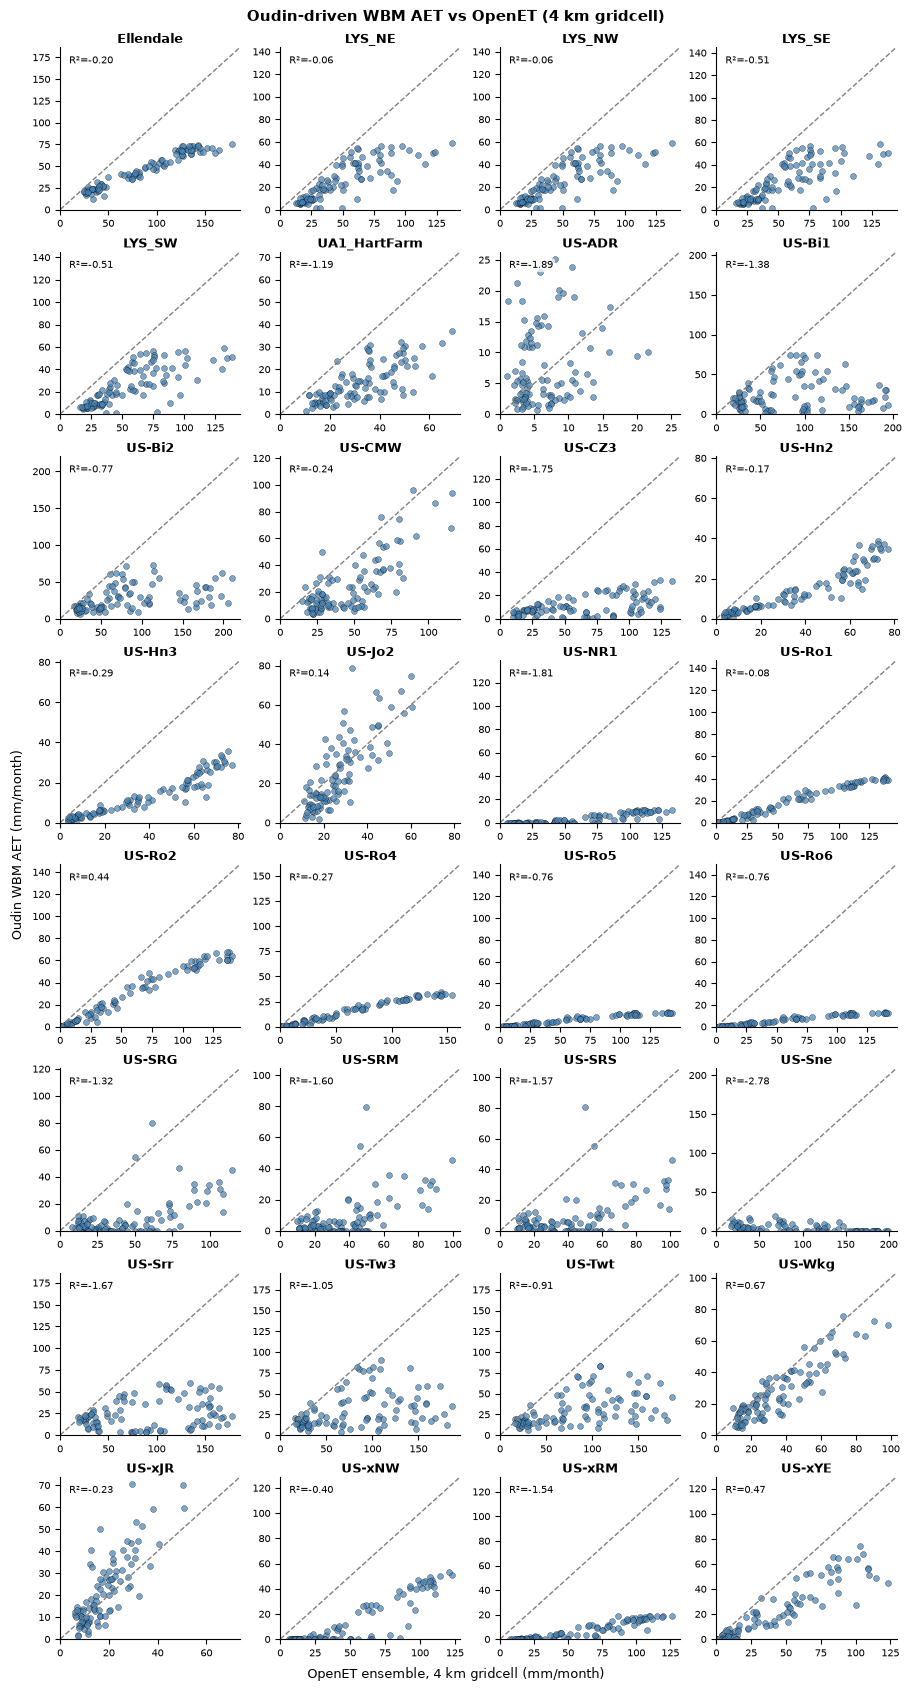

Saved to ../Data/pet_comparison/scatter_oudin_vs_openet.png


In [6]:
def make_scatter_facets(combined_df, metrics_df, pred_col, pred_label, title,
                         save_path, n_cols=4):
    """Faceted 1:1 scatter: WBM AET (pred_col) vs OpenET ensemble, one panel
    per site, annotated with each site's R\u00b2 from metrics_df."""
    sites_list = sorted(combined_df["site"].unique())
    n_rows = int(np.ceil(len(sites_list) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(9, n_rows * 2.1),
                              constrained_layout=True)
    axes_flat = np.atleast_1d(axes).flatten()

    for ax, site in zip(axes_flat, sites_list):
        sub = combined_df[combined_df["site"] == site].dropna(
            subset=["et_ensemble_gc_mm", pred_col])
        m = metrics_df[metrics_df["site"] == site]

        ax.scatter(sub["et_ensemble_gc_mm"], sub[pred_col],
                   s=18, color="steelblue", alpha=0.7,
                   edgecolors="k", linewidths=0.3)

        if not sub.empty:
            lims = [0, max(sub["et_ensemble_gc_mm"].max(), sub[pred_col].max()) * 1.05]
            ax.plot(lims, lims, color="grey", linestyle="--", linewidth=1, zorder=1)
            ax.set_xlim(lims)
            ax.set_ylim(lims)

        r2v = m["R2"].iloc[0] if not m.empty and m["note"].iloc[0] == "" else np.nan
        ax.annotate(f"R\u00b2={r2v:.2f}" if pd.notna(r2v) else "n/a",
                    xy=(0.05, 0.9), xycoords="axes fraction", fontsize=7,
                    bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                              alpha=0.7, edgecolor="none"))
        ax.set_title(site, fontsize=9, fontweight="bold", pad=3)
        ax.tick_params(labelsize=7)
        ax.spines[["top", "right"]].set_visible(False)

    for ax in axes_flat[len(sites_list):]:
        ax.set_visible(False)

    fig.supxlabel("OpenET ensemble, 4 km gridcell (mm/month)", fontsize=9)
    fig.supylabel(pred_label, fontsize=9)
    fig.suptitle(title, fontsize=11, fontweight="bold")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved to {save_path}")


make_scatter_facets(
    combined, metrics_oudin_vs_openet, pred_col="aet_oudin_mm",
    pred_label="Oudin WBM AET (mm/month)",
    title="Oudin-driven WBM AET vs OpenET (4 km gridcell)",
    save_path="../Data/pet_comparison/scatter_oudin_vs_openet.png",
)


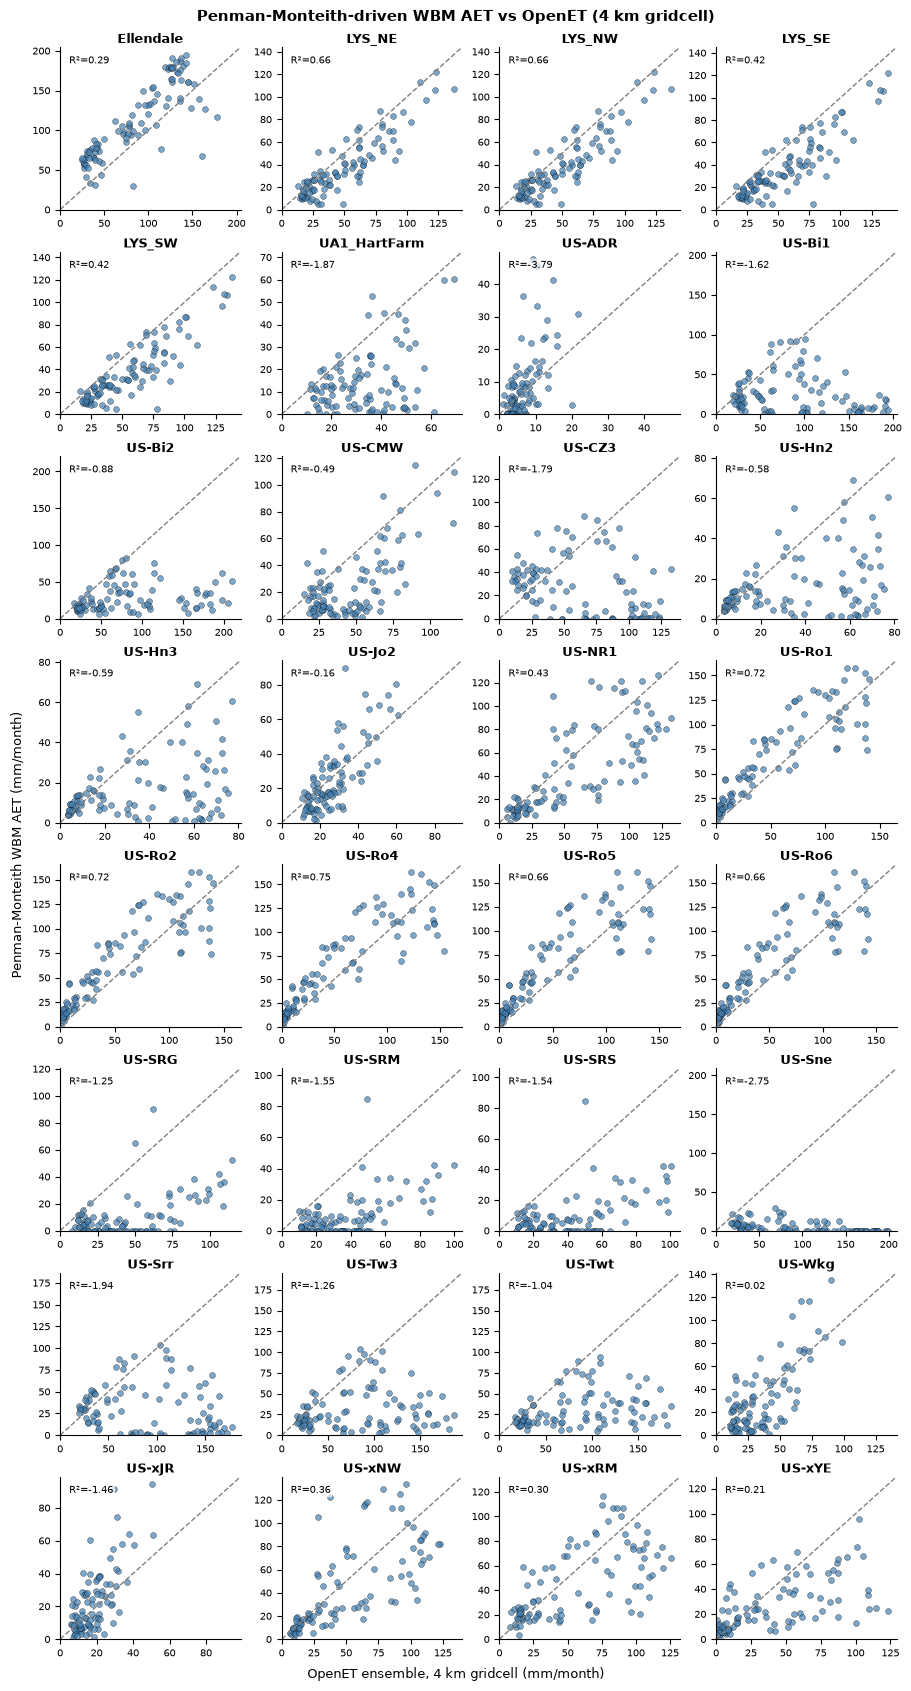

Saved to ../Data/pet_comparison/scatter_pm_vs_openet.png


In [7]:
make_scatter_facets(
    combined, metrics_pm_vs_openet, pred_col="aet_pm_mm",
    pred_label="Penman-Monteith WBM AET (mm/month)",
    title="Penman-Monteith-driven WBM AET vs OpenET (4 km gridcell)",
    save_path="../Data/pet_comparison/scatter_pm_vs_openet.png",
)


Mean RMSE vs OpenET by ecosystem (mm/month):
        ecosystem  RMSE_oudin  RMSE_pm
        Croplands       50.00    39.14
Evergreen Forests       52.38    38.09
       Grasslands       35.97    29.55
       Shrublands       21.59    23.37
 Wetland/Riparian       74.34    76.38


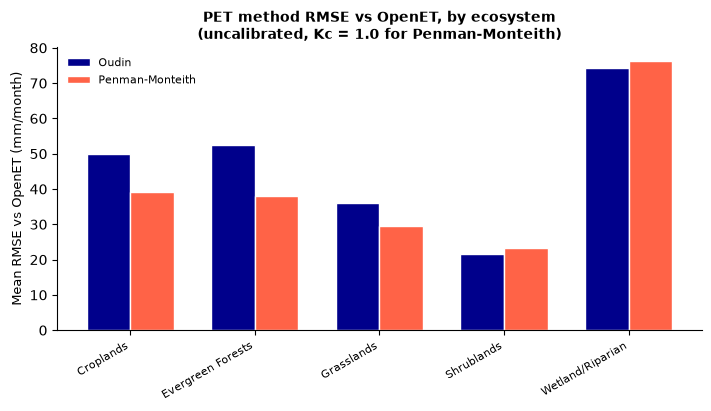

Saved to Data/pet_comparison/rmse_by_ecosystem_oudin_vs_pm.png


In [8]:
eco_lookup = combined[["site", "ecosystem"]].drop_duplicates()

eco_rmse = (
    metrics_oudin_vs_openet[metrics_oudin_vs_openet["note"] == ""]
    [["site", "RMSE"]].rename(columns={"RMSE": "RMSE_oudin"})
    .merge(
        metrics_pm_vs_openet[metrics_pm_vs_openet["note"] == ""]
        [["site", "RMSE"]].rename(columns={"RMSE": "RMSE_pm"}),
        on="site", how="outer"
    )
    .merge(eco_lookup, on="site", how="left")
)

eco_summary = (
    eco_rmse.groupby("ecosystem")[["RMSE_oudin", "RMSE_pm"]]
    .mean().round(2).reset_index()
)
print("Mean RMSE vs OpenET by ecosystem (mm/month):")
print(eco_summary.to_string(index=False))

ecosystems = eco_summary["ecosystem"].tolist()
x = np.arange(len(ecosystems))
w = 0.35

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
ax.bar(x - w / 2, eco_summary["RMSE_oudin"], width=w, color="darkblue",
       label="Oudin", edgecolor="white")
ax.bar(x + w / 2, eco_summary["RMSE_pm"], width=w, color="tomato",
       label="Penman-Monteith", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(ecosystems, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("Mean RMSE vs OpenET (mm/month)", fontsize=9)
ax.set_title("PET method RMSE vs OpenET, by ecosystem\n"
             "(uncalibrated, Kc = 1.0 for Penman-Monteith)",
             fontsize=10, fontweight="bold")
ax.legend(fontsize=8, frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.savefig("../Data/pet_comparison/rmse_by_ecosystem_oudin_vs_pm.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved to Data/pet_comparison/rmse_by_ecosystem_oudin_vs_pm.png")


### Step 5 — Timeseries: OpenET, Oudin, Penman-Monteith, and Flux tower, per site

Faceted monthly AET timeseries (one panel per site) showing OpenET (4 km
gridcell ensemble), both WBM runs, and the flux tower's own AET together.

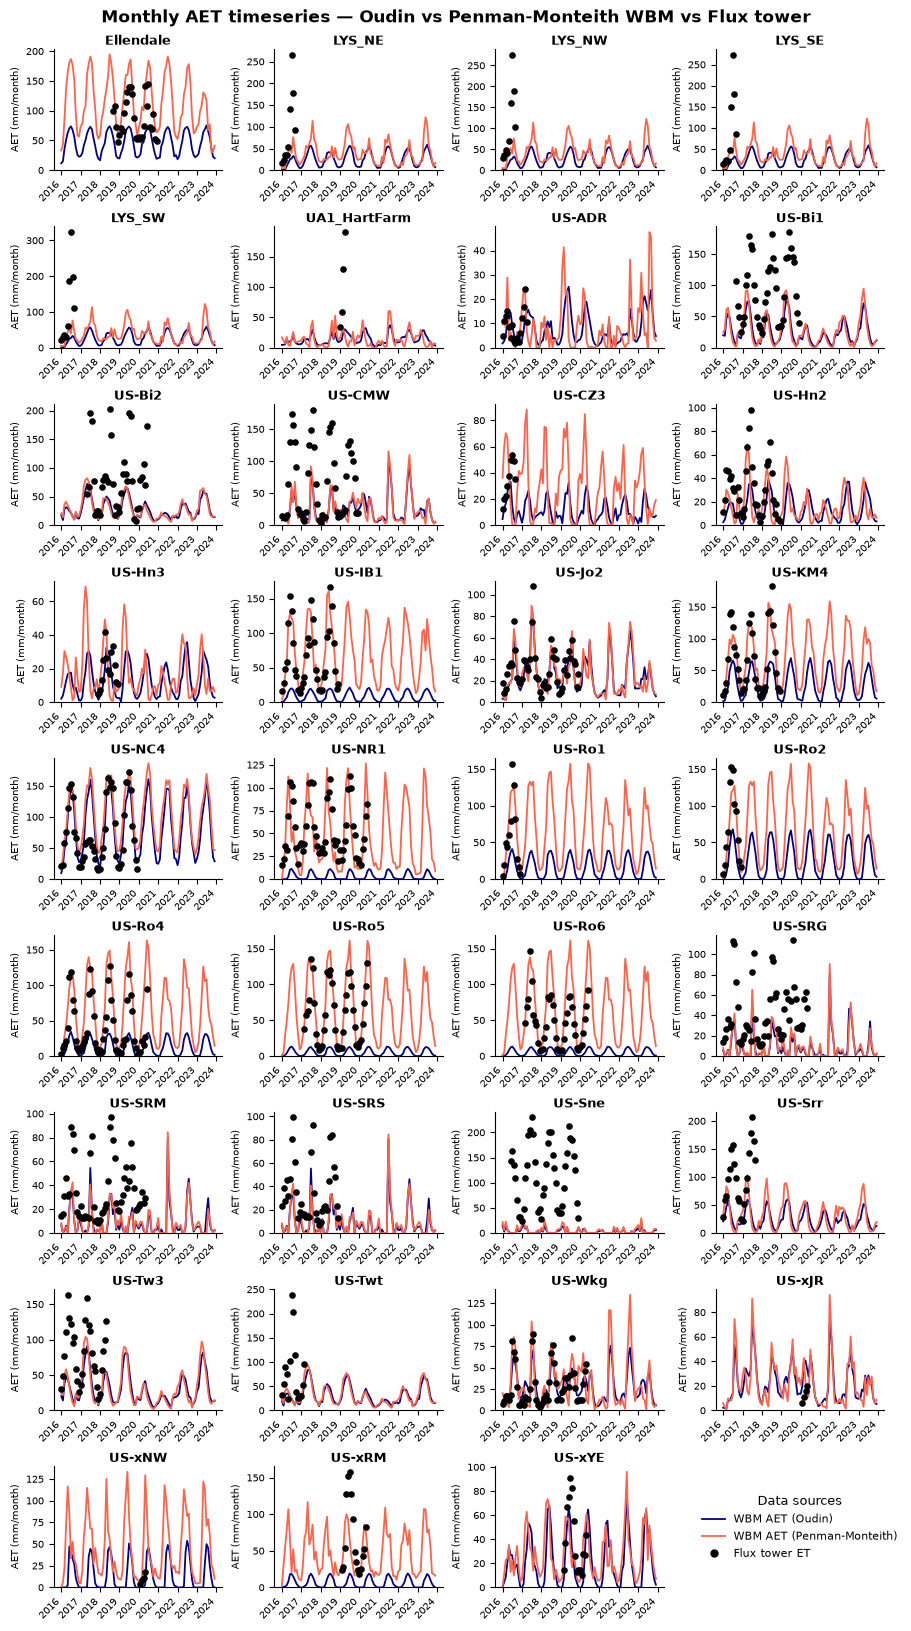

Saved to Data/pet_comparison/timeseries_oudin_pm_flux.png


In [9]:
# ── Timeseries: OpenET, Oudin AET, Penman-Monteith AET, and Flux tower AET, per site ──
flux_plot = to_month_start(
    flux_monthly[["site", "date", "ET_corr"]].rename(columns={"ET_corr": "aet_flux_mm"})
)

combined_ts = (
    openet_gc_plot
    .merge(oudin_plot, on=["site", "date"], how="outer")
    .merge(pm_plot,    on=["site", "date"], how="outer")
    .merge(flux_plot,  on=["site", "date"], how="outer")
    .sort_values(["site", "date"])
    .reset_index(drop=True)
)

sites_list = sorted(combined_ts["site"].unique())
n_cols = 4
n_rows = int(np.ceil(len(sites_list) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(9, n_rows * 1.8),
                          sharey=False, constrained_layout=True)
axes_flat = np.atleast_1d(axes).flatten()

for ax, site in zip(axes_flat, sites_list):
    sub = combined_ts[combined_ts["site"] == site].sort_values("date")

    ax.plot(sub["date"], sub["et_ensemble_gc_mm"],
            color="#1a5e2a", linewidth=1.3, linestyle="-",
            label="OpenET ensemble (4 km gridcell)", zorder=3)
    ax.plot(sub["date"], sub["aet_oudin_mm"],
            color="darkblue", linewidth=1.3, linestyle="-",
            label="WBM AET (Oudin)", zorder=4)
    ax.plot(sub["date"], sub["aet_pm_mm"],
            color="tomato", linewidth=1.3, linestyle="-",
            label="WBM AET (Penman-Monteith)", zorder=5)

    flux_sub = sub.dropna(subset=["aet_flux_mm"])
    if not flux_sub.empty:
        ax.scatter(flux_sub["date"], flux_sub["aet_flux_mm"],
                   color="black", s=14, zorder=8, label="Flux tower ET")

    ax.set_title(site, fontsize=9, fontweight="bold", pad=3)
    ax.set_ylabel("AET (mm/month)", fontsize=7)
    ax.tick_params(axis="both", labelsize=7)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_ylim(bottom=0)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

for ax in axes_flat[len(sites_list):]:
    ax.set_visible(False)

if len(sites_list) < len(axes_flat):
    legend_ax = axes_flat[len(sites_list)]
    legend_ax.set_visible(True)
    legend_ax.axis("off")
    legend_ax.legend(
        handles=[
            mlines.Line2D([], [], color="#1a5e2a", linewidth=1.3,
                          label="OpenET ensemble (4 km gridcell)"),
            mlines.Line2D([], [], color="darkblue", linewidth=1.3,
                          label="WBM AET (Oudin)"),
            mlines.Line2D([], [], color="tomato", linewidth=1.3,
                          label="WBM AET (Penman-Monteith)"),
            mlines.Line2D([], [], color="black", linewidth=0, marker="o",
                          markersize=5, label="Flux tower ET"),
        ],
        loc="center", fontsize=8, frameon=False,
        title="Data sources", title_fontsize=9,
    )

fig.suptitle("Monthly AET timeseries \u2014 OpenET vs Oudin vs Penman-Monteith WBM vs Flux tower",
             fontsize=12, fontweight="bold")
plt.savefig("../Data/pet_comparison/timeseries_openet_oudin_pm_flux.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved to Data/pet_comparison/timeseries_openet_oudin_pm_flux.png")


### Step 6 — Per-site metrics: bias / RMSE / R² vs. Flux tower

Same metric definitions as Step 3, applied to `combined_ts` (built in Step 5,
so this also picks up any site-months present for flux tower / WBM but
missing from the OpenET merge).

In [ ]:
metrics_oudin_vs_flux = compute_metrics(combined_ts, obs_col="aet_flux_mm", pred_col="aet_oudin_mm")
metrics_pm_vs_flux    = compute_metrics(combined_ts, obs_col="aet_flux_mm", pred_col="aet_pm_mm")

for label, mdf in [("Oudin WBM vs Flux tower", metrics_oudin_vs_flux),
                    ("Penman-Monteith WBM vs Flux tower", metrics_pm_vs_flux)]:
    valid = mdf[mdf["note"] == ""]
    print(f"\n\u2500\u2500 {label} \u2500\u2500")
    print(mdf[["site", "n", "slope", "MBE", "MAE", "RMSE", "R2", "note"]].to_string(index=False))
    if not valid.empty:
        print(f"  mean  : slope={valid['slope'].mean():.3f}  MBE={valid['MBE'].mean():.2f}  "
              f"RMSE={valid['RMSE'].mean():.2f}  R2={valid['R2'].mean():.3f}  (n={len(valid)} sites)")

metrics_oudin_vs_flux.to_csv("../Data/pet_comparison/oudin_vs_flux_metrics.csv", index=False)
metrics_pm_vs_flux.to_csv("../Data/pet_comparison/pm_vs_flux_metrics.csv", index=False)
print("\nSaved to Data/pet_comparison/{oudin_vs_flux_metrics,pm_vs_flux_metrics}.csv")


### Step 7 — Spatial map: which PET method matches OpenET better, by site?

Maps `RMSE(Penman-Monteith) − RMSE(Oudin)` (both vs. OpenET, from Step 3) at
each site's location -- negative (one color) means Penman-Monteith had lower
RMSE there, positive (the other color) means Oudin did.

In [ ]:
import geopandas as gpd
import matplotlib.colors as mcolors

# ── Merge each method's RMSE (vs OpenET) with site coordinates ────────────────
map_df = (
    metrics_oudin_vs_openet[metrics_oudin_vs_openet["note"] == ""][["site", "RMSE"]]
    .rename(columns={"RMSE": "RMSE_oudin"})
    .merge(
        metrics_pm_vs_openet[metrics_pm_vs_openet["note"] == ""][["site", "RMSE"]]
        .rename(columns={"RMSE": "RMSE_pm"}),
        on="site", how="inner"
    )
    .merge(flux_towers[["site", "x", "y", "ecosystem"]], on="site", how="left")
    .dropna(subset=["x", "y"])
    .reset_index(drop=True)
)
map_df["RMSE_diff"] = map_df["RMSE_pm"] - map_df["RMSE_oudin"]

print(f"Sites mapped: {len(map_df)}")
print(map_df[["site", "ecosystem", "RMSE_oudin", "RMSE_pm", "RMSE_diff"]]
      .round(2).to_string(index=False))

# ── US state boundaries (same fallback chain as notebook 04; degrades to a
# points-only map with no basemap if neither source is reachable) ────────────
states_conus = None
for _url in [
    "https://www2.census.gov/geo/tiger/GENZ2020/shp/cb_2020_us_state_20m.zip",
    "https://raw.githubusercontent.com/nvkelso/"
    "natural-earth-vector/master/geojson/"
    "ne_110m_admin_1_states_provinces.geojson",
]:
    try:
        states = gpd.read_file(_url)
        NON_CONUS = ["Alaska", "Hawaii", "Puerto Rico", "Guam",
                     "United States Virgin Islands", "American Samoa",
                     "Commonwealth of the Northern Mariana Islands"]
        name_col = "NAME" if "NAME" in states.columns else "name"
        states_conus = states[~states[name_col].isin(NON_CONUS)].copy()
        break
    except Exception as e:
        print(f"  (could not load state boundaries from {_url}: {e})")

if states_conus is not None:
    LON_MIN, LON_MAX = -125, -65
    LAT_MIN, LAT_MAX =   24,  50
else:
    print("No basemap source reachable -- plotting site points only.")
    pad = 3
    LON_MIN, LON_MAX = map_df["x"].min() - pad, map_df["x"].max() + pad
    LAT_MIN, LAT_MAX = map_df["y"].min() - pad, map_df["y"].max() + pad

abs_max = max(np.ceil(map_df["RMSE_diff"].abs().max() / 5) * 5, 5)
norm = mcolors.TwoSlopeNorm(vmin=-abs_max, vcenter=0, vmax=abs_max)

fig, ax = plt.subplots(figsize=(9, 6), constrained_layout=True)
if states_conus is not None:
    states_conus.plot(ax=ax, color="whitesmoke", edgecolor="grey", linewidth=0.4, zorder=1)
else:
    ax.set_facecolor("#f7f7f7")
    ax.grid(True, color="white", linewidth=1, zorder=1)
ax.set_xlim(LON_MIN, LON_MAX)
ax.set_ylim(LAT_MIN, LAT_MAX)
ax.set_aspect("equal")
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.set_xlabel("Longitude", fontsize=9)
ax.set_ylabel("Latitude", fontsize=9)

sizes = (map_df["RMSE_diff"].abs() / abs_max * 300).clip(lower=40)
sc = ax.scatter(
    map_df["x"], map_df["y"],
    c=map_df["RMSE_diff"], s=sizes, cmap="RdBu_r", norm=norm,
    edgecolors="k", linewidths=0.6, zorder=5, alpha=0.9,
)
for _, row in map_df.iterrows():
    ax.annotate(row["site"], xy=(row["x"], row["y"]), xytext=(6, 4),
                textcoords="offset points", fontsize=7, zorder=6)

cbar = fig.colorbar(sc, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label(
    "RMSE(Penman-Monteith) \u2212 RMSE(Oudin) vs OpenET, mm/month\n"
    "negative = Penman-Monteith better  |  positive = Oudin better",
    fontsize=8,
)
cbar.ax.tick_params(labelsize=7)

ax.set_title("Which PET method matches OpenET better, by site?",
             fontsize=12, fontweight="bold")
plt.savefig("../Data/pet_comparison/map_oudin_vs_pm_rmse_diff.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved to Data/pet_comparison/map_oudin_vs_pm_rmse_diff.png")


### Summary & suggested follow-ups

This is an uncalibrated, side-by-side benchmark of both PET methods against
OpenET and flux tower ET -- it doesn't apply any bias correction or
PET-multiplier calibration (see notebook 04 for that, currently only applied
to the Oudin run). Natural follow-ups:

- Apply notebook 04's PET-multiplier calibration to the Penman-Monteith run
  too, and compare *calibrated* RMSE/R² between methods instead of raw.
- Try an ecosystem-specific `Kc` instead of the `Kc = 1.0` baseline used for
  the ETo → PET conversion (see notebook 06's banner).